# Two coupled $0$-$\pi$: $n_{\theta 1}\otimes n_{\theta 2}$

### 1. Define variable transform

$1->\phi_1, 2->\theta_1, 3->\chi_1, 4->\Sigma_1$

$5->\phi_2, 6->\theta_2, 7->\chi_2, 8->\Sigma_2$

$9->\varphi_9, 10->Ground$

In [1]:
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores

In [2]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
# ut.set_fig_font() ### Set various sizes in plotting

### 2. Get circuit Hamiltonian

EC_theta = 0.092,   EC_phi = 1.142,   

EC = 1. / (0.5/EC_theta - 0.5/EC_phi) = 0.20012190476190478

Ec0=0.275  -->  g=0.0922

In [3]:
zp = scq.Circuit(ut.zp_yml, from_file=False)
zp.configure(transformation_matrix=np.linalg.inv(ut.transform_2zeropi))
zp.sym_hamiltonian()
print(zp.var_categories)
print(zp.cutoff_names)
zp.Ec0

<IPython.core.display.Latex object>

{'periodic': [2, 6], 'extended': [1, 3, 5, 7], 'free': [4, 8, 9], 'frozen': [], 'sigma': []}
['cutoff_n_2', 'cutoff_n_6', 'cutoff_ext_1', 'cutoff_ext_3', 'cutoff_ext_5', 'cutoff_ext_7']


1.0

### 3. Construct subsystem, calculate eigenvalues

In [4]:
trunc_dim = 10
system_hierarchy = [[1,2],  [5,6]]
subsystem_trunc_dims = [trunc_dim, trunc_dim]
zp.configure(system_hierarchy=system_hierarchy, subsystem_trunc_dims=subsystem_trunc_dims)

zp.cutoff_ext_1 = 100
zp.cutoff_n_2 = 30
zp.cutoff_ext_5 = 100
zp.cutoff_n_6 = 30

eval0, eket0 = zp.subsystems[0].eigensys(evals_count=trunc_dim)
eval1, eket1 = zp.subsystems[1].eigensys(evals_count=trunc_dim)
eval0 = eval0 - eval0[0]
eval1 = eval1 - eval1[0]
eket0 = ssp.csr_matrix([eket0[:,idx] for idx in range(trunc_dim)])
eket1 = ssp.csr_matrix([eket1[:,idx] for idx in range(trunc_dim)])

print(np.shape(eket1))
# zp.subsystems[0].n2_operator()
zp.sym_interaction((1,0))  # show coupling terms between subsystems 0 and 1
zp.sym_hamiltonian(subsystem_index=0)
zp.sym_hamiltonian(subsystem_index=1)
# print( zp.subsystems[0].ng2, '  ', zp.subsystems[1].ng6)
# print( zp.subsystems[0].external_flux_values(), '  ', zp.subsystems[1].external_flux_values())

(10, 6100)


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 4. Sort bare system eigenvalues, get dressed index

In [5]:
eval_bare_1d = []
order_1d = []
for idx, val0 in enumerate(eval0):
    for jdx, val1 in enumerate(eval1):
        eval_bare_1d.append(val0 + val1)
        order_1d.append(str(idx) + str(jdx))
eval_bare_2d = np.reshape(eval_bare_1d, (trunc_dim, trunc_dim) )
order_2d = np.reshape(order_1d, (trunc_dim, trunc_dim) )

sort_idx = np.argsort(eval_bare_1d)
eval_bare_sort = np.sort(eval_bare_1d)
order_sort2 = [order_1d[i] for i in sort_idx]
# H_bare = qt.Qobj(np.diag(eval_bare_sort), dims=[[trunc_dim, trunc_dim]] * 2)

print(order_sort2[:100])
print(order_sort2.index('52'))

['00', '01', '10', '02', '03', '20', '30', '04', '11', '40', '05', '06', '21', '31', '50', '60', '12', '13', '07', '70', '08', '22', '32', '23', '33', '14', '80', '41', '09', '24', '34', '90', '15', '16', '51', '61', '42', '43', '17', '71', '25', '35', '26', '36', '18', '52', '53', '62', '63', '27', '37', '81', '44', '72', '73', '28', '38', '19', '91', '54', '64', '82', '83', '45', '46', '47', '74', '29', '39', '92', '93', '55', '65', '56', '66', '48', '84', '57', '67', '75', '76', '77', '58', '68', '49', '94', '85', '86', '78', '87', '59', '69', '95', '96', '88', '79', '97', '98', '89', '99']
45


### 5. Get total Hamiltonian in dressed basis

In [6]:
# get the representation of the n_b operator in the dressed eigenbasis of the composite system
n_theta1 = (eket0 @ zp.subsystems[0].n2_operator() @ eket0.conj().T).todense()
n_theta2 = (eket1 @ zp.subsystems[1].n6_operator() @ eket1.conj().T).todense()
Hint = qt.tensor(qt.Qobj(n_theta1) , qt.Qobj(n_theta2))

n2, n6 = symbols('n2 n6')
g = zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6)
H_bare = (  qt.tensor(qt.Qobj(np.diag(eval0)),  qt.identity(trunc_dim))
          +  qt.tensor(qt.identity(trunc_dim),  qt.Qobj(np.diag(eval1))) )
Htot = g* Hint + H_bare
eval_tot, eket_tot = Htot.eigenstates()
eval_tot = eval_tot - eval_tot[0]

n_theta2_dress = qt.tensor(qt.identity(trunc_dim) , qt.Qobj(n_theta2))
n_theta2_dress_mat = np.zeros((trunc_dim**2, trunc_dim**2), dtype=complex)
for idx, vec1 in enumerate(eket_tot):
    for jdx, vec2 in enumerate(eket_tot):
        n_theta2_dress_mat[idx, jdx] = np.array(vec1.dag()* n_theta2_dress* vec2)

print(eval0[:trunc_dim])
print(eval1[:trunc_dim])
print(eval_tot[:trunc_dim])
# print(eval_tot - eval_bare_sort)

 /tmp/ipykernel_1821707/1830594281.py: 18

[0.         2.57833619 3.46860175 3.46925132 5.02328691 5.98779296
 5.99192592 6.56960929 7.30101168 8.26924378]
[0.         2.42796084 3.43468205 3.43600949 4.71843782 5.78629457
 5.79590763 6.21297858 6.83838296 7.8417131 ]
[0.         2.40945649 2.59570434 3.43469334 3.43602052 3.46860976
 3.46925931 4.69778163 4.9502724  5.09676586]


In [7]:
np.shape(n_theta2_dress_mat)

(100, 100)

In [8]:
bare_state = [[qt.tensor(qt.basis(trunc_dim, i), qt.basis(trunc_dim, j))
                    for j in range(trunc_dim)]
                        for i in range(trunc_dim)]
order_sort = []
for i in range(trunc_dim**2):
    overlaps = np.array([[np.abs(eket_tot[i].overlap(bare_state[j][k])) for k in range(trunc_dim)] for j in range(trunc_dim)])
    idx = np.unravel_index(np.argmax(overlaps), overlaps.shape)
    if (str(idx[0])+str(idx[1])) not in order_sort:
        order_sort.append(str(idx[0])+str(idx[1]))
    else:
        overlaps[idx[0], idx[1]] = 0
        idx2 = np.unravel_index(np.argmax(overlaps), overlaps.shape)
        order_sort.append(str(idx2[0])+str(idx2[1]))
for i in range(100):
    print(i,'  ', order_sort2[i], order_sort[i])


0    00 00
1    01 01
2    10 10
3    02 02
4    03 03
5    20 20
6    30 30
7    04 04
8    11 40
9    40 11
10    05 05
11    06 06
12    21 21
13    31 31
14    50 50
15    60 60
16    12 12
17    13 13
18    07 07
19    70 70
20    08 08
21    22 22
22    32 32
23    23 23
24    33 33
25    14 80
26    80 14
27    41 41
28    09 09
29    24 24
30    34 34
31    90 90
32    15 15
33    16 16
34    51 61
35    61 51
36    42 42
37    43 43
38    17 17
39    71 71
40    25 25
41    35 35
42    26 26
43    36 36
44    18 18
45    52 52
46    53 53
47    62 62
48    63 63
49    27 81
50    37 27
51    81 37
52    44 44
53    72 72
54    73 73
55    28 28
56    38 38
57    19 19
58    91 91
59    54 83
60    64 82
61    82 64
62    83 54
63    45 46
64    46 45
65    47 47
66    74 74
67    29 29
68    39 39
69    92 92
70    93 93
71    55 48
72    65 65
73    56 66
74    66 55
75    48 56
76    84 84
77    57 57
78    67 67
79    75 75
80    76 76
81    77 58
82    58 77
83    68 49
84

## Decompose a superposition state

In [9]:
state_idx = '45'
idx = order_sort.index(state_idx)
overlap_idx = []
overlap_big = []
for j in range(trunc_dim):
    for k in range(trunc_dim):
        overlap = np.abs(eket_tot[idx].overlap(bare_state[j][k]))
        if  overlap > 0.1:
            overlap_idx.append((j,k))
            overlap_big.append(overlap)
print(f'The state {state_idx} is a superposition of {overlap_idx} with coresponding coefficients: {overlap_big}')

The state 45 is a superposition of [(1, 9), (4, 5), (8, 2)] with coresponding coefficients: [0.16155263127815175, 0.8425049093814263, 0.5125073807686773]


In [ ]:
logi_space = ['00', '02', '20',  '22']
# Get n_theta in dressed basis
N_a = qt.tensor(qt.Qobj(n_theta1), qt.identity(trunc_dim))
n_theta1_dress = np.zeros((trunc_dim**2, trunc_dim**2), dtype=complex)
N_b = qt.tensor(qt.identity(trunc_dim) , qt.Qobj(n_theta2))
n_theta2_dress = np.zeros((trunc_dim**2, trunc_dim**2), dtype=complex)
for idx, vec1 in enumerate(eket_tot):
    for jdx, vec2 in enumerate(eket_tot):
        n_theta1_dress[idx,jdx] = np.array(vec1.dag()* N_a* vec2).flatten()[0]
        n_theta2_dress[idx,jdx] = np.array(vec1.dag()* N_b* vec2).flatten()[0]

logi_index = [order_sort.index(x) for x in logi_space]
trunc_states = logi_space
logi_index

[0, 3, 5, 21]

#### only consider leakage directly from logical states

In [67]:
thresh_matrix_emt = 1e-0
for i in logi_index:
    for j in range(n_theta1_dress.shape[0]):
        if np.abs(n_theta1_dress[i,j]) > thresh_matrix_emt or np.abs(n_theta2_dress[i,j]) > thresh_matrix_emt:
            j_state = order_sort[j]
            if j_state not in trunc_states:
                trunc_states.append(j_state)
idxs = [order_sort.index(x) for x in trunc_states]
print('threshold=', thresh_matrix_emt)
print('num of truncation =', len(trunc_states))
print('hilbert_space :')
dim = 10
data = trunc_states
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 1.0
num of truncation = 28
hilbert_space :
00, 02, 20, 22, 01, 10, 05, 12, 08, 21 ,
50, 25, 52, 28, 80, 14, 41, 19, 91, 54 ,
48, 84, 82, 45, 59, 95, 98, 89 ,


#### consider leakage directly and indirectly from logical states

threshold= [1e-8,0.1]
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,

In [68]:
logi_index

[0, 3, 5, 21]

In [60]:
# logi_index = [order_sort.index(x) for x in logi_space]
threshold = 1e-1
hspace_charge = [0, 3, 5, 21]
for i in hspace_charge:
    for j in range(n_theta1_dress.shape[0]):
        if np.abs(n_theta2_dress[i,j]) > threshold and j not in hspace_charge:
            hspace_charge.append(j)    
print('threshold=', threshold)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.1
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,


In [15]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
threshold= 1e-08
num of truncation = 28
hilbert_space :
00, 02, 20, 22, 50, 01, 10, 05, 21, 12 ,
08, 80, 14, 41, 25, 52, 28, 19, 91, 82 ,
54, 45, 48, 84, 59, 95, 98, 89

[0, 3, 5, 21, 14, 1, 2, 20, 25, 26, 27, 10, 16, 60, 64, 12, 55, 40, 45, 58]

### 6. Matrix element

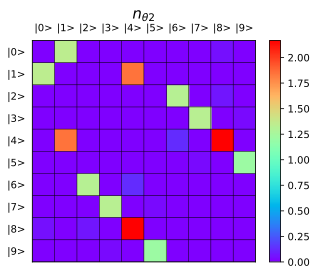

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
font_size = 15
plt.imshow(np.abs(n_theta2),aspect="auto",cmap='rainbow')
# plt.imshow(np.abs(n_theta2),aspect="auto",cmap='rainbow', norm=LogNorm(vmin = 10e-3,vmax = np.max(np.abs(n_theta2))))
plt.title('$n_{\\theta2}$' , pad=5,fontsize=font_size)
dim_plot = trunc_dim
# Major ticks
ax.set_xticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.set_yticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.xaxis.tick_top()
# Minor ticks
ax.set_xticks(np.arange(-.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-.5, 10, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
# Remove both ticks
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [ ]:
levels_label2 = ["00","02","20","22","05","50","25","52","55"]
level_idx = [order_sort.index(levels_label2[i]) for i in range(len(levels_label2))]
n_theta2_dress_extract = np.zeros((len(levels_label2), len(levels_label2)), dtype=complex)
for idx, level_i in enumerate(level_idx):
    for jdx, level_j in enumerate(level_idx):
        n_theta2_dress_extract[idx, jdx] = n_theta2_dress_mat[level_i, level_j]
qt.Qobj(np.round(np.abs(n_theta2_dress_extract), 3))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]

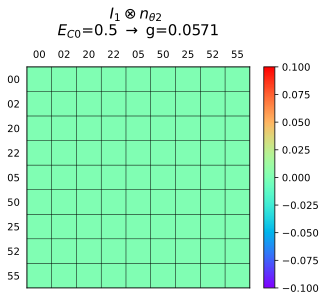

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
font_size = 15
plt.imshow(np.abs(n_theta2_dress_extract), aspect="auto", cmap='rainbow')
plt.title(r'$I_1\otimes n_{\theta 2}$ '+'\n$E_{C0}$=%.1f $\\to$ '%zp.Ec0 + 'g=%.4f'%g ,pad=15,fontsize=font_size)
ax = plt.gca();
# Major ticks
ax.set_xticks(np.arange(0, 9, 1), levels_label2)
ax.set_yticks(np.arange(0, 9, 1), levels_label2)
ax.xaxis.tick_top()
# Minor ticks
ax.set_xticks(np.arange(-.5, 9, 1), minor=True)
ax.set_yticks(np.arange(-.5, 9, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
# Remove both ticks
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()

### 7. Calculate 8 important transition energies

In [ ]:
# get the transition frequency between two states specified by dressed indices
def transition_frequency(s0: int, s1: int) -> float:
    return ( (   eval_tot[s1]- eval_tot[s0] )* 2* np.pi)

start_list = ['00', '00', '02', '02', '20', '20', '22', '22']
end_list   = ['01', '10', '12', '05', '50', '21', '52', '25']
eff_num = 5  # number of effective digits in np.round()

state_list = []
dw_list = []
mat_list= []
for i,j in zip(start_list, end_list):
    state_list.append(i + '-' + j)
    dw_list.append(np.abs( transition_frequency( order_sort.index(i) , order_sort.index(j) )))
    mat_list.append(np.abs(n_theta2_dress_mat[order_sort.index(i) , order_sort.index(j)]))

dw_num = len(dw_list)
sort_idxs    = np.array(dw_list).argsort()
state_list  = np.array([state_list[idx] for idx in sort_idxs])
mat_list  = np.array([mat_list[idx] for idx in sort_idxs])
dw_list = np.round( np.sort(dw_list), eff_num )

[print(state_list[i],' : ', dw_list[i], ' : ', mat_list[i]) for i in range(dw_num)];

22-25  :  10.52829  :  0.0
02-05  :  10.52832  :  0.0
22-52  :  12.1285  :  0.0
20-50  :  12.12853  :  0.0
20-21  :  14.86351  :  1.1514653513178654
00-01  :  14.92663  :  1.2011862586959496
02-12  :  16.47022  :  0.48361777496598
00-10  :  16.54274  :  0.594838961727937


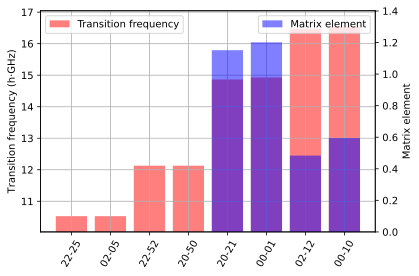

In [ ]:
transparency = 0.5
fig, ax = plt.subplots(figsize = (6,4));
#plt.title('$E_{J2}=0.9E_{J1}$')
plt.xticks(range(dw_num), state_list, rotation=60);
#plt.gca().get_xticklabels()[4].set_color('red')
plt.bar(range(dw_num), dw_list, label='Transition frequency', color='r', alpha=transparency)
plt.ylim(dw_list[0]-0.5, dw_list[-1]+0.5)
plt.ylabel('Transition frequency (h$\cdot$GHz)')
plt.legend(loc='upper left')
plt.grid()
plt.ylim(dw_list[0]-0.5,dw_list[-1]+0.5)

plt.twinx()  # Create a twin axes sharing the same x-axis
plt.bar(range(dw_num), mat_list, label='Matrix element', color='b', alpha=transparency)
plt.ylabel('Matrix element')
plt.legend(loc='upper right')
plt.ylim(0,np.max(mat_list)+0.2);
#plt.savefig('Python image/cz_matrix_element_histo.png',dpi=200,bbox_inches='tight')

### 8. Get dressed index for logical states

In [ ]:
# truncate operators to desired dimension
def truncate(operator: qt.Qobj, dimension: int) -> qt.Qobj:
    return qt.Qobj(operator[:dimension, :dimension])

###############################################
# convert the product states to the closes eigenstates of the dressed system
product_states = ['00', '20', '02', '22',
                  '01', '21', '05', '25',
                  '10', '50', '12', '52' ]
state0 = '20'
state1 = '50'
trans_freq = np.abs(transition_frequency(order_sort.index(state0) , order_sort.index(state1)))
print('drive frequency: ', trans_freq)

idxs = [order_sort.index(i) for i in product_states]
print('state index: ', idxs)
# The matrix representations can be truncated further for the simulation
total_truncation = np.max(idxs) +1

states = [qt.basis(total_truncation, idx) for idx in idxs]
computational_subspace = states[:4] # spanned by the first 4 states


drive frequency:  12.128529510706667
state index:  [0, 5, 3, 21, 1, 14, 9, 40, 2, 11, 16, 42]


### 9. Get drive Hamiltonian, Solve master equation and Plot

In [ ]:
# Gaussian pulse parameters optimized by hand
# drive_amp = 0.00537     #.005
# tg = 225
# detune = 0.0782
options = qt.Options(store_states=True)
tg = 112
detune=0.094
drive_amp=0.0089
tlist = np.linspace(0, tg, num=int(1*tg))  # total time
pulse_args = {'drive_amp': drive_amp, 'drive_freq': detune + trans_freq, 'gate_time': tg}

# The factor of 2pi converts the energy to GHz so that the time is in units of ns
diag_hamiltonian = 2 * np.pi * qt.Qobj(np.diag(eval_tot))
diag_hamiltonian_trunc = truncate(diag_hamiltonian, total_truncation)
N_b_trunc = truncate(n_theta2_dress_mat, total_truncation)
H_qbt_drive = [ diag_hamiltonian_trunc, [2* np.pi* N_b_trunc, ut.drive_coeff]  ]
result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(total_truncation, order_sort.index( str(state_i) + str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in states],
            args=pulse_args,options=options  )

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\omega_d$=%.4f'%trans_freq )
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res, label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)
# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

AttributeError: module 'utils_2Q_gate_zp' has no attribute 'drive_coeff'

In [ ]:
prop = qt.propagator(H_qbt_drive, tlist, args=pulse_args)[-1]  # get the propagator at the final time step
fidelity = ut.cz_fidelity(prop, computational_subspace, logi_states=states)
fidelity

0.999277851674597

In [ ]:
w20 = trans_freq
w22 = np.abs(transition_frequency(order_sort.index('22') ,order_sort.index('52')))
wd = detune + trans_freq
w20-w22, wd-w20

(0.06167198569913168, 0.09399999999999942)

In [ ]:
plt.plot(tlist[0:50], blochs[0][0:50], label='x')

NameError: name 'blochs' is not defined

In [ ]:
Ec0 = 1
tg = 112
detune=0.094
drive_amp=0.0089
# tg = 225
# detune = 0.0782
# drive_amp = 0.00537     #.005

drive_ab = False
state0 = '20'
state1 = '50'
one_drive = True
args = (Ec0, tg, drive_ab, state0, state1, one_drive)

args_indep = (detune, drive_amp)
fidelity = ut.get_fidelity(args_indep, *args)

print('fidelity=',fidelity)

AttributeError: module 'utils_2Q_gate_zp' has no attribute 'get_fidelity'

### 10. Fidelity

NameError: name 'fidelity' is not defined

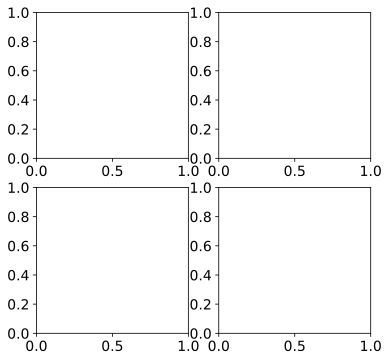

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\delta_\omega$=%.4f'%detune
             + '\n$T_g$=%.1f;  '%tg + 'F=%.6f'%fidelity, y=1.0)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']

for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res, label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')

        ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')

    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')

handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)
# plt.tight_layout()
# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

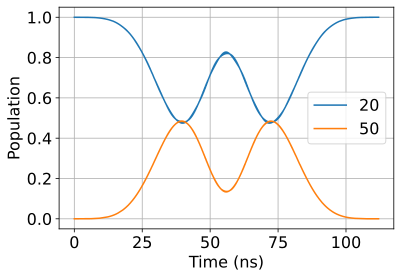

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
# for kdx, res in zip(idxs, result[1,0].expect):
#     ax.plot(tlist, res, label=r"%s" % order_sort[kdx])
ax.plot(tlist, result[1,0].expect[1], label=r"20" )
ax.plot(tlist, result[1,0].expect[9], label=r"50")
ax.grid()
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Population')
ax.legend()
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[::-1],labels[::-1],
#                 loc='center left',
#                 bbox_to_anchor=(0.8, 0.5)).get_frame().set_alpha(0.1)

### 11. Plot $\Delta\omega$ vs g


In [ ]:
Ec0_vec = np.linspace(0.5, 20, num=51 )
g_vec = []
Dw_vec = []
Dc_vec= []
na_20_50 = []
na_22_52 = []
nb_20_50 = []
nb_22_52 = []
n2, n6 = symbols('n2 n6')
for Ec0 in tqdm(Ec0_vec):
    zp = scq.Circuit(ut.zp_yml, from_file=False)
    zp.Ec0 = Ec0
    zp.configure(transformation_matrix=np.linalg.inv(ut.transform_2zeropi))

    system_hierarchy = [[1,2],  [5,6]]
    subsystem_trunc_dims = [trunc_dim, trunc_dim]
    zp.configure(system_hierarchy=system_hierarchy,
                subsystem_trunc_dims=subsystem_trunc_dims)
    # why we need 2*np.pi below
    g_vec.append(2*np.pi* zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6) )

    eval0, eket0 = zp.subsystems[0].eigensys(evals_count=trunc_dim)
    eval1, eket1 = zp.subsystems[1].eigensys(evals_count=trunc_dim)
    eval0 = eval0 - eval0[0]
    eval1 = eval1 - eval1[0]
    eket0 = ssp.csr_matrix([eket0[:,idx] for idx in range(trunc_dim)])
    eket1 = ssp.csr_matrix([eket1[:,idx] for idx in range(trunc_dim)])

    # Sort bare system eigenvalues, get dressed index
    eval_bare_1d = []
    order_1d = []
    for idx, val0 in enumerate(eval0):
        for jdx, val1 in enumerate(eval1):
            eval_bare_1d.append(val0 + val1)
            order_1d.append(str(idx) + str(jdx))
    eval_bare_2d = np.reshape(eval_bare_1d, (trunc_dim, trunc_dim) )
    order_2d = np.reshape(order_1d, (trunc_dim, trunc_dim) )

    sort_idx = np.argsort(eval_bare_1d)
    eval_bare_sort = np.sort(eval_bare_1d)
    order_sort = [order_1d[i] for i in sort_idx]

    # get eval_tot
    n_theta1 = np.zeros((trunc_dim, trunc_dim),dtype=complex)
    for idx, vec1 in enumerate(eket0):
        for jdx, vec2 in enumerate(eket0):
            n_theta1[idx,jdx] = (vec1 @ zp.subsystems[0].n2_operator() @ vec2.H).toarray()

    n_theta2 = np.zeros((trunc_dim, trunc_dim),dtype=complex)
    for idx, vec1 in enumerate(eket1):
        for jdx, vec2 in enumerate(eket1):
            n_theta2[idx,jdx] = (vec1 @ zp.subsystems[1].n6_operator() @ vec2.H).toarray()

    Hint = qt.tensor(qt.Qobj(n_theta1) , qt.Qobj(n_theta2))
    n2, n6 = symbols('n2 n6')
    g = zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6)
    H_bare = ( qt.tensor(qt.Qobj(np.diag(eval0)),  qt.identity(trunc_dim))
              +qt.tensor(qt.identity(trunc_dim),  qt.Qobj(np.diag(eval1))) )
    Htot = g* Hint + H_bare
    eval_tot, eket_tot = Htot.eigenstates()
    eval_tot = eval_tot - eval_tot[0]

    # get frequency differency
    Dw_vec.append(np.abs(  transition_frequency( order_sort.index('20') , order_sort.index('50') )
                         - transition_frequency( order_sort.index('22') , order_sort.index('52') )))
    Dc_vec.append(np.abs(  transition_frequency( order_sort.index('00') , order_sort.index('02') )
                         - transition_frequency( order_sort.index('20') , order_sort.index('22') )))

    # # calculate matrix element
    # N_a = qt.tensor(qt.Qobj(n_theta1), qt.identity(trunc_dim))
    # N_a_dress = np.zeros((trunc_dim**2, trunc_dim**2),dtype=complex)
    # for idx, vec1 in enumerate(eket_tot):
    #     for jdx, vec2 in enumerate(eket_tot):
    #         N_a_dress[idx,jdx] = np.array(vec1.dag()* N_a* vec2)

    # n_theta2_dress = qt.tensor(qt.identity(trunc_dim), qt.Qobj(n_theta2))
    # n_theta2_dress_mat = np.zeros((trunc_dim**2, trunc_dim**2),dtype=complex)
    # for idx, vec1 in enumerate(eket_tot):
    #     for jdx, vec2 in enumerate(eket_tot):
    #         n_theta2_dress_mat[idx,jdx] = np.array(vec1.dag()* n_theta2_dress* vec2)

    # na_20_50.append(N_a_dress[order_sort.index('20') , order_sort.index('50')])
    # na_22_52.append(N_a_dress[order_sort.index('22') , order_sort.index('52')])
    # nb_20_50.append(n_theta2_dress_mat[order_sort.index('20') , order_sort.index('50')])
    # nb_22_52.append(n_theta2_dress_mat[order_sort.index('22') , order_sort.index('52')])

g_vec = np.array(g_vec)
Dw_vec = np.array(Dw_vec)
Dc_vec = np.array(Dc_vec)

# na_20_50 = np.abs(np.array(na_20_50))
# na_22_52 = np.abs(np.array(na_22_52))
# nb_20_50 = np.abs(np.array(nb_20_50))
# nb_22_52 = np.abs(np.array(nb_22_52))

  0%|          | 0/51 [00:00<?, ?it/s]DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_2207124/1328189746.py: 47DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_2207124/1328189746.py: 52DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_2207124/1328189746.py: 74DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before perform

In [ ]:
print(g_vec.tolist())
print(Dw_vec.tolist())
print(Dc_vec.tolist())

[0.358864244227648, 0.216336231935270, 0.154836560284235, 0.120561677054915, 0.0987151840665070, 0.0835663747720797, 0.0724513806793897, 0.0639439853979427, 0.0572269209652474, 0.0517860828582155, 0.0472871299273390, 0.0435109755610668, 0.0402939601880351, 0.0375169905732470, 0.0350980496775065, 0.0329742203200603, 0.0310953185591174, 0.0294115349599148, 0.0279097617764623, 0.0265465561934780, 0.0253148025774243, 0.0241903452249764, 0.0231598891366299, 0.0222172549464179, 0.0213439045564401, 0.0205396507131821, 0.0197919474311964, 0.0191007947104828, 0.0184536465655935, 0.0178505029965286, 0.0172788180178403, 0.0167509503614621, 0.0162483619294938, 0.0157770448343878, 0.0153371863296584, 0.0149162404298577, 0.0145203865009527, 0.0141434451769764, 0.0137852292044147, 0.0134459258367818, 0.0131193557081108, 0.0128113236773403, 0.0125160248855318, 0.0122333657059281, 0.0119631588850151, 0.0117118646690309, 0.0114605704530467, 0.0112280952152342, 0.0110018929701456, 0.0107819637177809, 0.0

In [ ]:
1-10**-3.19

0.9993543457709654

Text(0, 0.5, '$\\Delta_\\omega$ (GHz)')

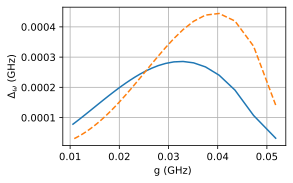

In [ ]:
cut = 9
fig, ax = plt.subplots(figsize=(4,2.5))
plt.plot(g_vec[cut:], Dw_vec[cut:], label='$\Delta_\omega$')
plt.plot(g_vec[cut:], 5e4*Dc_vec[cut:],'--', label='$\Delta_c \\times 50000$')
plt.grid()
plt.xlabel(r"g (GHz) ")
plt.ylabel(r"$\Delta_\omega$ (GHz)")
# plt.legend()

Text(0, 0.5, '$n_{i\\to j}$ (GHz)')

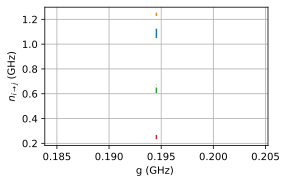

In [ ]:
cut = 1
fig, ax = plt.subplots(figsize=(4,2.5))
plt.plot(g_vec[cut:], na_20_50[cut:],  label='na_20_50')
plt.plot(g_vec[cut:], na_22_52[cut:],  label='na_22_52')
plt.plot(g_vec[cut:], nb_20_50[cut:], '--',  label='nb_20_50')
plt.plot(g_vec[cut:], nb_22_52[cut:], '--',  label='nb_22_52')
plt.grid()
plt.xlabel(r"g (GHz) ")
plt.ylabel(r"$n_{i\to j}$ (GHz)")
# plt.legend()

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

##### If 0.2<Ec0<5, 0.116>g>0.007, which means it's hard to get large g in this system.


In [ ]:
Ec0_vec = np.linspace(0.2, 5, num=31 )
g_vec = []
for EC0 in tqdm(Ec0_vec):
    zp.Ec0 = EC0
    g_vec.append(2*np.pi* zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6) )
g_vec = np.array(g_vec)

  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:09<00:00,  3.39it/s]


In [ ]:
print(Ec0_vec)
print(np.round(g_vec.astype(float), 3))
print(np.round(g_vec.astype(float)/(2*np.pi), 3))

[0.2  0.36 0.52 0.68 0.84 1.   1.16 1.32 1.48 1.64 1.8  1.96 2.12 2.28
 2.44 2.6  2.76 2.92 3.08 3.24 3.4  3.56 3.72 3.88 4.04 4.2  4.36 4.52
 4.68 4.84 5.  ]
[0.728 0.471 0.348 0.276 0.228 0.195 0.17  0.151 0.135 0.123 0.112 0.104
 0.096 0.09  0.084 0.079 0.075 0.071 0.067 0.064 0.061 0.058 0.056 0.054
 0.051 0.05  0.048 0.046 0.045 0.043 0.042]
[0.116 0.075 0.055 0.044 0.036 0.031 0.027 0.024 0.022 0.02  0.018 0.016
 0.015 0.014 0.013 0.013 0.012 0.011 0.011 0.01  0.01  0.009 0.009 0.009
 0.008 0.008 0.008 0.007 0.007 0.007 0.007]


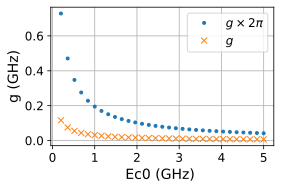

In [ ]:
cut = 0
fig, ax = plt.subplots(figsize=(4,2.5))
plt.plot(Ec0_vec[cut:], g_vec[cut:], '.', label='$g \\times 2\pi$')
plt.plot(Ec0_vec[cut:], g_vec[cut:]/(2*np.pi), 'x', label='$g $')
plt.grid()
plt.xlabel(r"Ec0 (GHz) ")
plt.ylabel(r"g (GHz)")
plt.legend()

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

### 12. Sweep over drive amplitude A and drive frequency wd


In [ ]:
tg = 180
num_t = 400
tlist = np.linspace(0, tg, num_t)  # total time
#################################################################################
A_vec = np.linspace(drive_amp-0.01, drive_amp+0.013, num=21)
wd_vec = np.linspace(trans_freq - 0.08, trans_freq + 0.08, num=21)

fidelity = []
for A in tqdm(A_vec):
    for wd in wd_vec:
        result = {}
        logi_state = [0,2]
        for idx, state_i in enumerate(logi_state):
            for jdx, state_j in enumerate(logi_state):
                # This simulation is just for viewing the affect of the pulse
                result[idx, jdx] = qt.mesolve(
                    H_qbt_drive,
                    qt.basis(total_truncation, order_sort.index( str(state_i) + str(state_j) )),
                    tlist,
                    e_ops=[state * state.dag() for state in states],
                    args={'drive_amp': A, 'drive_freq': wd }
                )

        ##### Propagator calculation #######
        # The computational subspace is spanned by the first 4 states
        min11_idx = np.argmin(result[1,0].expect[1][:int(num_t/2)])

        computational_subspace = states[:4]

        # get the propagator at the final time step
        prop = qt.propagator(H_qbt_drive,
                            tlist,
                            args={'drive_amp': A, 'drive_freq': trans_freq })[2*min11_idx]

        # truncate the propagator to the computational subspace
        Uc = qt.Qobj([ [prop.matrix_element(s1, s2) for s1 in computational_subspace]
                    for s2 in computational_subspace  ])

        # product of single-qubit Z-gates
        Uz = remove_global_phase(qt.tensor(rz(dphi(states[2])), rz(dphi(states[1]))))
        Uc_reshaped = qt.Qobj(Uc.data, dims=[[2, 2], [2, 2]])
        Ucprime = remove_global_phase(Uz * Uc_reshaped)
        # fidelity measure given on page 3 of Nesterov et al.
        fidelity.append(np.round( ((Ucprime.dag() * Ucprime).tr()
                        + np.abs((Ucprime.dag() * cz_gate()).tr()) ** 2) / 20, 6) )
        # print(np.round( ((Ucprime.dag() * Ucprime).tr()
                        # + np.abs((Ucprime.dag() * cz_gate()).tr()) ** 2) / 20, 6))
# print( 'A=', A, '; $\omega_d$=', w_d, '; F=', fidelity )
# Tgate = np.round(tlist[2*min11_idx],2)
# print('gate time:', Tgate,'(ns)')
fidelity = np.reshape(np.array(fidelity), (len(A_vec), len(wd_vec)))
print(fidelity)

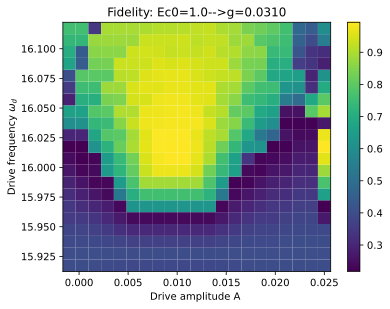

In [ ]:
fig, ax = plt.subplots(figsize=(6,4.5))
plt.pcolormesh(A_vec, wd_vec, fidelity)
plt.colorbar()
plt.title(r"Fidelity: "+'Ec0=%.1f-->'%zp.Ec0 + 'g=%.4f'%g)
plt.xlabel(r"Drive amplitude A ")
plt.ylabel(r"Drive frequency $\omega_d$");

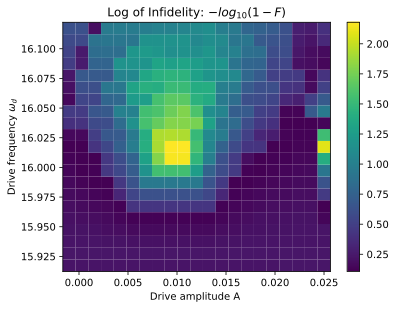

In [ ]:
fig, ax = plt.subplots(figsize=(6,4.5))
plt.pcolormesh(A_vec, wd_vec, -np.log10(1-fidelity))
plt.colorbar()
plt.title(r"Log of Infidelity: $-log_{10}(1-F)$")
plt.xlabel(r"Drive amplitude A ")
plt.ylabel(r"Drive frequency $\omega_d$");

In [ ]:
qt.Qobj(fidelity)

Quantum object: dims = [[25], [25]], shape = (25, 25), type = oper, isherm = False
Qobj data =
[[0.388438 0.387904 0.384206 0.383583 0.379042 0.373616 0.362102 0.349821
  0.349821 0.349821 0.349821 0.349821 0.349821 0.349821 0.349821 0.349821
  0.349821 0.349821 0.362478 0.369192 0.378704 0.383583 0.383925 0.38816
  0.388438]
 [0.377252 0.376219 0.369157 0.367972 0.360118 0.34945  0.328958 0.30818
  0.30818  0.30818  0.30818  0.30818  0.30818  0.30818  0.30818  0.30818
  0.30818  0.30818  0.32961  0.350087 0.358816 0.367972 0.370183 0.376715
  0.377252]
 [0.362906 0.361265 0.350213 0.350213 0.336365 0.32047  0.291469 0.264211
  0.264211 0.264211 0.264211 0.264211 0.264211 0.264211 0.264211 0.264211
  0.264211 0.264211 0.292352 0.32141  0.334389 0.348368 0.351806 0.362052
  0.362906]
 [0.359701 0.343662 0.3284   0.3284   0.309812 0.289265 0.272662 0.238928
  0.225282 0.225282 0.225282 0.225282 0.225282 0.225282 0.225282 0.225282
  0.225282 0.236976 0.255366 0.29046  0.307194 0.32587  0.

In [ ]:
max_index = np.unravel_index(np.argmax(fidelity), fidelity.shape)
print("Indices of the maximum value:", max_index)
print(A_vec[max_index[0]], wd_vec[max_index[1]])
fidelity[max_index]


Indices of the maximum value: (10, 11)
0.010333333333333332 15.990600858763152


0.994569

### 13. g vs Eval

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

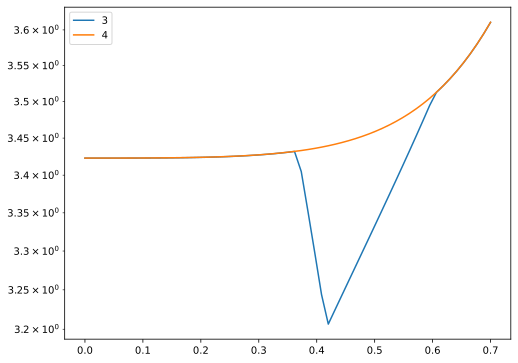

In [ ]:
g_vec = np.linspace(0, 0.7, num=61)
num_track = 100
energy = []
for g in g_vec:
    Htot = g* Hint + H_bare
    eval_tot = Htot.eigenenergies(eigvals = num_track)
    energy.append(eval_tot - eval_tot[0])
energy = np.array(energy)

fig, ax = plt.subplots(figsize=(8,6))
for i in np.arange(3,5):
    plt.plot(g_vec, energy[:,i], label=str(i))
plt.yscale('log')
plt.legend()

### 14. other

Ec0:   [ 0.2   1.86  3.52  5.18  6.84  8.5  10.16 11.82 13.48 15.14 16.8  18.46
 20.12 21.78 23.44 25.1  26.76 28.42 30.08 31.74 33.4  35.06 36.72 38.38
 40.04 41.7  43.36 45.02 46.68 48.34 50.  ]
Dw:   [1.01e+00 3.10e-02 1.30e-02 7.00e-03 5.00e-03 3.00e-03 2.00e-03 2.00e-03
 1.00e-03 1.00e-03 1.00e-03 1.00e-03 1.00e-03 1.00e-03 1.00e-03 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]


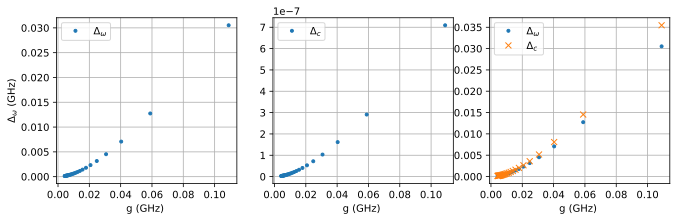

In [ ]:
=
cut = 1
fig, ax = plt.subplots(figsize=(11,3), ncols=3)
ax[0].plot(g_vec[cut:], Dw_vec[cut:], '.', label='$\Delta_\omega$')
ax[0].set_ylabel(r"$\Delta_\omega$ (GHz)")
ax[1].plot(g_vec[cut:], Dc_vec[cut:], '.', label='$\Delta_c$')
ax[2].plot(g_vec[cut:], Dw_vec[cut:], '.', label='$\Delta_\omega$')
ax[2].plot(g_vec[cut:], 5e4*Dc_vec[cut:], 'x', label='$\Delta_c$')
for i in range(3):
    ax[i].legend()
    ax[i].grid()
    ax[i].set_xlabel(r"g (GHz) ")
print('Ec0:  ', np.round(Ec0_vec, 2))
print('Dw:  ', np.round(Dw_vec, 3))

In [ ]:
# print(zp.offset_charges)
# print(zp.offset_charge_values())
# zp.ng2 = 0.
zp.operators_by_name
dir(zp.subsystems[0])
[x for x in dir(zp.subsystems[0]) if "op" in x.lower()]

['I_operator',
 'Q1_operator',
 'Qs1_operator',
 '_interaction_operator_from_expression',
 '_kron_operator',
 '_make_property',
 '_replace_mat_mul_operator',
 '_set_property_and_update_cutoffs',
 '_set_property_and_update_ext_flux_or_charge',
 '_set_property_and_update_param_vars',
 'circuit_operator_functions',
 'cosθ1_operator',
 'cosθ2_operator',
 'esys_method_options',
 'evals_method_options',
 'exp_i_pos_operator',
 'get_operator_by_name',
 'get_operator_names',
 'n2_operator',
 'operator_names_in_hamiltonian_symbolic',
 'operators_by_name',
 'process_op',
 'set_operators',
 'sinθ1_operator',
 'sinθ2_operator',
 'θ1_operator']

In [ ]:
g12 = 0.2
g1r = 0.15
g2r = g1r
Ecr = 0.1

I1 = ssp.identity(trunc_dim, format='csc', dtype='float64')
I2 = I1
Ir = ssp.identity(dim_res, format='csc', dtype='float64')

n1_theta = zp1.matrixelement_table(operator='n_theta_operator', evals_count=trunc_dim)
n2_theta = zp2.matrixelement_table(operator='n_theta_operator', evals_count=trunc_dim)
nr = (resonator.creation_operator() - resonator.annihilation_operator()) / (np.sqrt(2)* 1j)

H1 = 2* np.pi* np.diag(zp1.eigenvals(evals_count=trunc_dim))
H2 = 2* np.pi* np.diag(zp2.eigenvals(evals_count=trunc_dim))
Hr = 4* Ecr* nr**2

Htot = (  kr([H1, I2, Ir])
        + kr([I1, H2, Ir])
        + kr([I1, I2, Hr])
        + kr([n1_theta, n2_theta, Hr])* g12
        + kr([n1_theta, I2,       nr])* g1r
        + kr([I1,       n2_theta, nr])* g2r )

In [ ]:
# Hamiltonian in dressed eigenbasis
(evals,) = hspace["evals"]
# The factor of 2pi converts the energy to GHz so that the time is in units of ns
diag_dressed_hamiltonian = (
    2 * np.pi * qt.Qobj(np.diag(evals), dims=[hspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian_trunc = truncate(diag_dressed_hamiltonian, total_truncation)


In [ ]:
import functools as ft
def kr(matrix_list):
    return ft.reduce(ssp.kron, matrix_list)

Id = ssp.identity((2*n_cut+1)*phi_cut, format='csc', dtype='float64')

Htot = (  kr([zp1.hamiltonian(), Id]) + kr([Id, zp2.hamiltonian()]) )

evals, _ = ssp.linalg.eigsh(Htot, k=10, which='SA', tol=1.e-10)
sort_idxs = evals.argsort()
evals_fixed  = np.sort(evals) - np.min(evals)

In [ ]:
# truncate operators to desired dimension
def truncate(operator: qt.Qobj, dimension: int) -> qt.Qobj:
    return qt.Qobj(operator[:dimension, :dimension])

# get the transition frequency between two states specified by dressed indices
def transition_frequency(s0: int, s1: int) -> float:
    return ( (   hspace.energy_by_dressed_index(s1)
            - hspace.energy_by_dressed_index(s0) )
            * 2* np.pi)

# Factor global phase so that upper-left corner of matrix is real
def remove_global_phase(op):
    return op * np.exp(-1j * cmath.phase(op[0, 0]))

# The process for obtaining the Z rotations is taken from page 3 of Nesterov et al., at the
# bottom of the paragraph beginning, "To model gate operation..."
def dphi(state):
    return (-np.angle(prop.matrix_element(state, state))
            +np.angle(prop.matrix_element(states[0], states[0])) )

In [ ]:
hspace = scq.HilbertSpace([zp1, zp2, resonator])
g12 = 0.2
g1r = 0.15
g2r = g1r

#hspace.add_interaction(g=g, op1=zp1.i_d_dphi_operator, op2=zp2.i_d_dphi_operator)
hspace.add_interaction(g=g12, op1=zp1.n_theta_operator, op2=zp2.n_theta_operator)
hspace.add_interaction(g=g1r,
                       op1=zp1.n_theta_operator,
                       op2=resonator.creation_operator() + resonator.annihilation_operator())
hspace.add_interaction(g=g2r,
                       op1=zp2.n_theta_operator,
                       op2=resonator.creation_operator() + resonator.annihilation_operator())
hspace.generate_lookup()

#### $E_C-C$

In [ ]:
Ec = 10
e = 1.6e-19
h = 6.63e-34
C = 0.5* e**2 / (Ec*h * 1e9)
C

1.9306184012066362e-15

#### $E_L-L$

In [ ]:
El = 30
phi0 = 2.07e-15
L = (0.5*phi0/np.pi)**2 / (El*h*1e9)
L

5.456902209515499e-09